# Лабораторная работа 4

Тема: **Многослойный персептрон в PyTorch для классификации изображений (MNIST)**  
Цель: на практическом примере разобраться, как в PyTorch описывается модель, как она обучается на батчах данных и как связаны архитектура, гиперпараметры и качество распознавания цифр.

> ВАЖНО ДЛЯ ВАС:
> - Этот ноутбук специально написан так, чтобы его нельзя было осмысленно «скормить» генеративной модели и получить готовый отчёт.  
> - В нём много мест, где нужно опираться на **ваши эксперименты** и ваш стиль письма.  
> - Преподаватель смотрит на согласованность: код ↔ графики ↔ текст. Шаблонные ответы и типовой «ИИ‑стиль» легко заметны.


## 1. Ваше понимание задачи (коротко, по‑человечески)

Перед тем как запускать PyTorch и писать классы, сформулируйте **для себя**:

1. Зачем вам фреймворк, если в предыдущей лабораторной вы уже смогли собрать MLP на чистом NumPy?  
2. Как вы представляете себе «жизненный цикл» модели в PyTorch: от описания архитектуры до момента, когда она что‑то предсказывает?  
3. Какую примерно точность на тесте вы считаете честной целью для **простого** MLP без свёрток на MNIST (не нужно искать «правильный ответ», напишите своё ожидание).

Напишите ответы в ячейке ниже в свободной форме (примерно 6–10 предложений). Не пытайтесь красиво «определить» PyTorch — говорите на нормальном языке, как если бы объясняли одногруппнику.


In [60]:
intro_text = """ЗДЕСЬ НАПИШИТЕ СВОЁ ПОНИМАНИЕ ЗАДАЧИ.
Можно использовать списки, можно писать сплошным текстом.
Главное — это ваш собственный взгляд, а не пересказ документации PyTorch.

1. PyTorch может дать преимущество в скорости вычислений в отличии от NumPy. В прошлой лабе я так и не дождался выполнения кода с 10 тыс. нейронов скрытого слоя (возможно, с фреймворком эта проблема решится)
Также PyTorch может строить динамические графики, которые будут наглядно показывать процесс построения, а не уже готовы результат.

2. Описать модель, задать слои, выбрать функцию активации, подготовить данные, разбить данные на train/test, выбрать функцию потерь, провести цикл обучения, сохранить модель, получить предсказание.

3. Я считаю, что процентов 80 точно будет, потому что даже самые простые модели смогут отличить 1 от 6, например."""
print(intro_text)

ЗДЕСЬ НАПИШИТЕ СВОЁ ПОНИМАНИЕ ЗАДАЧИ.
Можно использовать списки, можно писать сплошным текстом.
Главное — это ваш собственный взгляд, а не пересказ документации PyTorch.

1. PyTorch может дать преимущество в скорости вычислений в отличии от NumPy. В прошлой лабе я так и не дождался выполнения кода с 10 тыс. нейронов скрытого слоя (возможно, с фреймворком эта проблема решится)
Также PyTorch может строить динамические графики, которые будут наглядно показывать процесс построения, а не уже готовы результат.

2. Описать модель, задать слои, выбрать функцию активации, подготовить данные, разбить данные на train/test, выбрать функцию потерь, провести цикл обучения, сохранить модель, получить предсказание.

3. Я считаю, что процентов 80 точно будет, потому что даже самые простые модели смогут отличить 1 от 6, например.


## 2. Импорт библиотек и настройка

Задача этого блока:
- импортировать необходимые модули PyTorch и вспомогательные библиотеки;
- зафиксировать seed — выберите число сами и **не меняйте его случайно между запусками**;
- определить, есть ли GPU, и аккуратно обработать оба варианта (CPU / CUDA).

Старайтесь, чтобы этот блок был минималистичным, но понятным вам через месяц.


In [61]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Выберите и зафиксируйте свой seed (запишите число отдельно в отчёте)
MY_SEED = 0 # можете поменять, но затем используйте это значение последовательно
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)
print("MY_SEED =", MY_SEED)

Используемое устройство: cpu
MY_SEED = 0


## 3. Подготовка данных MNIST

Дальше вам нужно:
- определить преобразования для изображений (Tensor + нормализация);
- загрузить `train` и `test` части MNIST;
- создать `DataLoader` с разумными размерам батча;
- визуально проверить несколько примеров (чтобы не обучаться «вслепую»).

Нормализацию можно сделать стандартной для MNIST или подобрать свою. В отчёте потом объясните, что выбрали и почему.


Размер train: 60000
Размер test : 10000
batch_size = 64
Ваши mean=0.1307, std=0.3081
Стандартные: mean=0.1307, std=0.3081


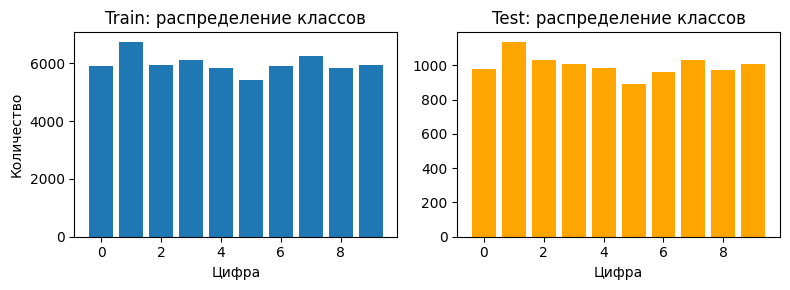

In [62]:
# ПОДГОТОВКА ПРЕОБРАЗОВАНИЙ
transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.1307,), (0.3081,))  # можно поменять, но тогда прокомментируйте это в отчёте
])

# ЗАГРУЗКА ДАТАСЕТА
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

# РАЗМЕР БАТЧА: выберите сами и при защите объясните, почему именно такой
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))
print("batch_size =", batch_size)

# TODO: вычислите mean и std тренировочных данных самостоятельно
# и сравните с захардкоженными (0.1307, 0.3081)
all_pixels = torch.cat([img.view(-1) for img, _ in train_dataset])
mean = all_pixels.mean()
std  = all_pixels.std()
print(f"Ваши mean={mean:.4f}, std={std:.4f}")
print(f"Стандартные: mean=0.1307, std=0.3081")

# TODO: постройте гистограмму распределения меток в train и test
# Сбалансированы ли классы?
all_labels = [lbl for _, lbl in train_dataset]
unique, counts = np.unique(all_labels, return_counts=True)

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.bar(unique, counts)
plt.title("Train: распределение классов")
plt.xlabel("Цифра"); plt.ylabel("Количество")

test_labels = [lbl for _, lbl in test_dataset]
unique_t, counts_t = np.unique(test_labels, return_counts=True)
plt.subplot(1, 2, 2)
plt.bar(unique_t, counts_t, color="orange")
plt.title("Test: распределение классов")
plt.xlabel("Цифра")
plt.tight_layout(); plt.show()

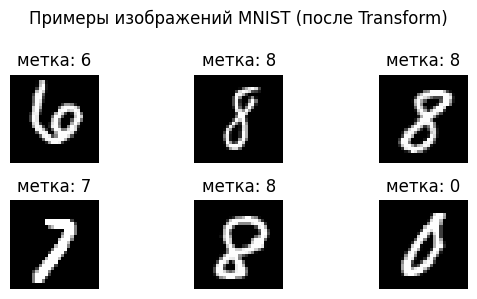

In [63]:
# ВИЗУАЛЬНАЯ ПРОВЕРКА НЕСКОЛЬКИХ ПРИМЕРОВ
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"метка: {labels[i].item()}")
    plt.axis("off")

plt.suptitle("Примеры изображений MNIST (после Transform)")
plt.tight_layout()
plt.show()

### Краткий комментарий к данным (заполните сами)

Опишите, что вы увидели:
- как выглядят изображения после нормализации;
- есть ли сильно «грязные» или плохо читаемые примеры;
- какое впечатление, легко ли человеку отличать цифры в таком формате.

Это не формальная часть — просто зафиксируйте свои наблюдения.


In [64]:
data_comment = """ЗДЕСЬ КРАТКО ОПИШИТЕ СВОИ ВПЕЧАТЛЕНИЯ О ДАННЫХ.
Например: какие цифры выглядят аккуратнее/хуже всего,
сложно ли человеку самим глазом перепутать некоторые пары цифр и т.п.

Сильно грязных или плохо читаемых примеров нет, только, может быть ноль, но он все равно хорошо выглядит.
Я думаю, что человеку легко отличать цифры в таком формате
Убрал нормализацию, чтобы корректно посчитать свои mean и std -> они совпадают с захардкоженными"""
print(data_comment)

ЗДЕСЬ КРАТКО ОПИШИТЕ СВОИ ВПЕЧАТЛЕНИЯ О ДАННЫХ.
Например: какие цифры выглядят аккуратнее/хуже всего,
сложно ли человеку самим глазом перепутать некоторые пары цифр и т.п.

Сильно грязных или плохо читаемых примеров нет, только, может быть ноль, но он все равно хорошо выглядит.
Я думаю, что человеку легко отличать цифры в таком формате
Убрал нормализацию, чтобы корректно посчитать свои mean и std -> они совпадают с захардкоженными


## 4. Архитектура многослойного персептрона

Теперь нужно описать модель.

**Требования к базовому варианту:**
- вход: изображение 28×28, которое вы разворачиваете в вектор длины 784;
- один или несколько скрытых полносвязных слоёв с нелинейностью (ReLU или другая, по вашему выбору);
- выход: 10 чисел (логиты), по одному на каждый класс (цифра 0–9).

Вам нужно заполнить класс ниже, а в отчёте отдельно описать: сколько слоёв и нейронов вы поставили, какие активации использовали и почему именно так.


In [ ]:
class MNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: замените архитектуру на свою (изменения архитектуры должны сопровождаться пояснениями)
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
            # более компактное сжатие, чтобы не переобучить модель
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.net(x)
        return logits

model = MNISTMLP().to(device)
print(model)

MNISTMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


## 5. Функция потерь и оптимизатор

Для многоклассовой классификации на MNIST обычно используют:
- `nn.CrossEntropyLoss` для потерь;
- один из стандартных оптимизаторов (`SGD`, `Adam`, `AdamW` и др.).

Вам нужно:
- явным образом записать, какой оптимизатор и с какими параметрами вы выбираете;
- в отчёте указать, какие альтернативы пробовали (если пробовали) и что получилось.


In [66]:
criterion = nn.CrossEntropyLoss()

# Попробуйте несколько вариантов lr и типов оптимизаторов в разных запусках и сравните разные комбинации
learning_rate = 1e-1
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

# TODO: Выведите число обучаемых параметров модели
print("Число обучаемых параметров модели: ")
for param in model.parameters():
    print(param.size())


Функция потерь: CrossEntropyLoss()
Оптимизатор: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    weight_decay: 0.01
)
learning_rate = 0.1
Число обучаемых параметров модели: 
torch.Size([128, 784])
torch.Size([128])
torch.Size([64, 128])
torch.Size([64])
torch.Size([10, 64])
torch.Size([10])


## 6. Функции обучения и оценки модели

Ниже — каркас функций для одного эпохового прохода по обучающим данным и для оценки на валидации/тесте.

Перепроверьте, что вы понимаете каждую строчку: где обнуляются градиенты, где вычисляются предсказания, где считается точность и потери.

Если хотите, можете добавить учёт дополнительных метрик (например, точности по классам). Главное — не потерять базовую ясность.


In [67]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 7. Обучение модели: история потерь и точности

Теперь запускаем обучение на несколько эпох.

**Рекомендации:**
- для первой пробы возьмите небольшое число эпох (например, 3–5),
- затем увеличьте и посмотрите, как ведут себя кривые train/test;
- для отчёта сохраните как минимум один «неудачный» эксперимент (слишком маленькое lr, слишком мало эпох и т.д.) — он полезнее, чем идеальная картинка.


In [68]:
num_epochs = 5  # изменяйте это значение и фиксируйте результаты в отчёте

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

Эпоха 1/5: train_loss=2.4390, train_acc=0.1024, test_loss=2.3510, test_acc=0.1028
Эпоха 2/5: train_loss=2.3475, train_acc=0.1520, test_loss=1.9338, test_acc=0.2710
Эпоха 3/5: train_loss=1.7605, train_acc=0.3145, test_loss=1.7310, test_acc=0.3508
Эпоха 4/5: train_loss=1.5154, train_acc=0.3743, test_loss=1.5086, test_acc=0.3791
Эпоха 5/5: train_loss=1.5078, train_acc=0.3789, test_loss=1.6014, test_acc=0.3949


In [69]:
lr_optim_comment = """ЗДЕСЬ УКАЖИТЕ ЗАПУСКИ ОБУЧЕНИЯ С РАЗНЫМИ ОПТИМИЗАТОРАМИ И СКОРОСТЯМИ ОБУЧЕНИЯ.

optimizer = SGD; lr = 1e-3; num_epochs = 5; test_acc = 0.9766
optimizer = Adam; lr = 1e-3; num_epochs = 5; test_acc = 0.9802
optimizer = AdamW; lr = 1e-1; num_epochs = 10; test_acc = 0.5891 (начал стремительно падать на 6 эпохе)
optimizer = Adafactor; lr = 1e-1; num_epochs = 5; test_acc = 0.9820
optimizer = Adafactor; lr = 1e-1; num_epochs = 10; test_acc = 0.9824
"""
print(lr_optim_comment)

ЗДЕСЬ УКАЖИТЕ ЗАПУСКИ ОБУЧЕНИЯ С РАЗНЫМИ ОПТИМИЗАТОРАМИ И СКОРОСТЯМИ ОБУЧЕНИЯ.

optimizer = SGD; lr = 1e-3; num_epochs = 5; test_acc = 0.9766
optimizer = Adam; lr = 1e-3; num_epochs = 5; test_acc = 0.9802
optimizer = AdamW; lr = 1e-1; num_epochs = 10; test_acc = 0.5891 (начал стремительно падать на 6 эпохе)
optimizer = Adafactor; lr = 1e-1; num_epochs = 5; test_acc = 0.9820
optimizer = Adafactor; lr = 1e-1; num_epochs = 10; test_acc = 0.9824



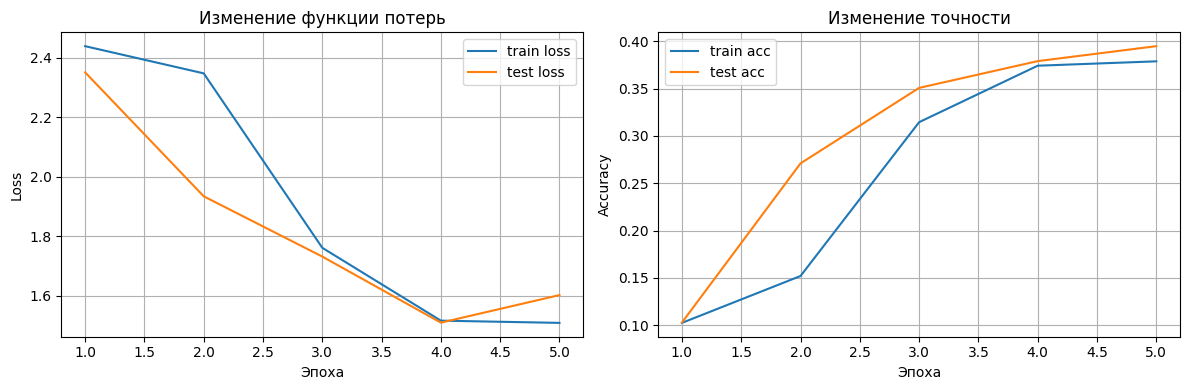

Финальная точность: train=0.3789, test=0.3949


In [70]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["test_loss"], label="test loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Изменение функции потерь")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["test_acc"], label="test acc")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Изменение точности")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная точность: train={history['train_acc'][-1]:.4f}, test={history['test_acc'][-1]:.4f}")

### Ваш комментарий по кривым обучения

Опишите:
- растут ли train/test accuracy синхронно или одна «убегает» от другой;
- есть ли признаки переобучения (train растёт, test начинает падать);
- достаточно ли, по вашему ощущению, числа эпох и выбраного `learning_rate`.

Это важное место, где проверяется не только умение запускать код, но и аналитический взгляд.


In [71]:
training_comment = """ЗДЕСЬ ОПИШИТЕ, КАК ВЕЛИ СЕБЯ КРИВЫЕ LOSS/ACCURACY.
Сошлитесь на конкретные цифры (например, точности на первой и последней эпохах),
и напишите, какие изменения параметров вы бы попробовали дальше.

train и test accuracy в целом растут (иногда опускаются - в случае с большим lr) синхронно, больших отклонений не обнаружено.
Признаков переобучения тоже не обнаружено. Только немного заметно в 3-ем случае с AdamW, где train немного растет, а test немного опускается.
По моим ощущениям, числа эпох и lr достаточно, потому что во многих случаях accuracy доходит до 98%, что уже неплохо."""
print(training_comment)

ЗДЕСЬ ОПИШИТЕ, КАК ВЕЛИ СЕБЯ КРИВЫЕ LOSS/ACCURACY.
Сошлитесь на конкретные цифры (например, точности на первой и последней эпохах),
и напишите, какие изменения параметров вы бы попробовали дальше.

train и test accuracy в целом растут (иногда опускаются - в случае с большим lr) синхронно, больших отклонений не обнаружено.
Признаков переобучения тоже не обнаружено. Только немного заметно в 3-ем случае с AdamW, где train немного растет, а test немного опускается.
По моим ощущениям, числа эпох и lr достаточно, потому что во многих случаях accuracy доходит до 98%, что уже неплохо.


## 8. Ошибки модели: что она путает

Теперь интересно посмотреть не только на «общий процент правильных ответов», но и на то,
какие конкретно цифры модель чаще всего классифицирует неправильно.

Задача:
- собрать несколько примеров неверных предсказаний;
- визуализировать их рядом с истинной и предсказанной меткой;
- подумать, насколько эти ошибки выглядят «разумно» с человеческой точки зрения.


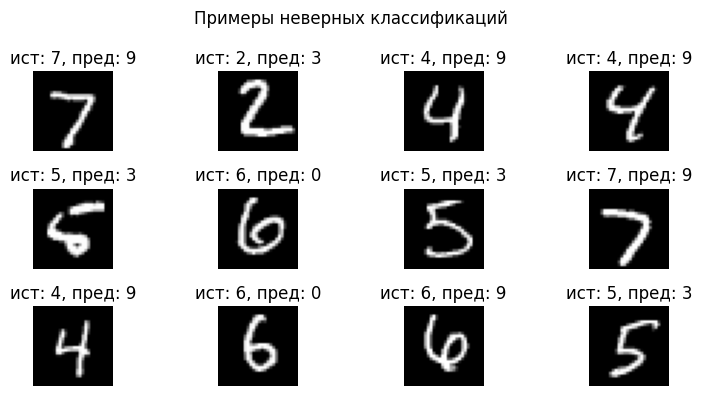

    Пред.  Ист.
0       9     7
1       3     2
2       9     4
3       9     4
4       3     5
5       0     6
6       3     5
7       9     7
8       9     4
9       0     6
10      9     6
11      3     5


In [72]:
model.eval()
wrong_images = []
wrong_true = []
wrong_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        mismatched = preds != labels
        if mismatched.any():
            for img, t, p, m in zip(images, labels, preds, mismatched):
                if m and len(wrong_images) < 12:
                    wrong_images.append(img.cpu())
                    wrong_true.append(t.cpu().item())
                    wrong_pred.append(p.cpu().item())
        if len(wrong_images) >= 12:
            break

plt.figure(figsize=(8, 4))
for i in range(len(wrong_images)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(wrong_images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"ист: {wrong_true[i]}, пред: {wrong_pred[i]}")
    plt.axis("off")
plt.suptitle("Примеры неверных классификаций")
plt.tight_layout()
plt.show()

# TODO: Постройте матрицу ошибок

import pandas as pd
matrix_errors = pd.DataFrame({
    "Пред.": wrong_pred,
    "Ист.": wrong_true
})
print(matrix_errors)

### Краткий анализ ошибок (заполните сами)

Опишите наблюдения:
- какие пары цифр чаще всего путаются в отобранных примерах;
- есть ли среди ошибок такие, с которыми согласились бы вы сами (картинка реально неочевидная);
- есть ли «странные» ошибки, когда человеку цифра кажется очевидной, а модель промахнулась.


In [73]:
errors_comment = """ЗДЕСЬ ОПИШИТЕ ПАРУ НАБЛЮДЕНИЙ ПО ОШИБКАМ.
Попробуйте указать, какие цифры чаще всего путаются, и насколько это видно на картинках.

Чаще всего путаются цифры (5,3) и (2,6). Среди ошибок нет таких, с которыми бы я согласился, все цифры хорошо различаются.
Есть странные ошибки, например, модель перепутала 4 и предсказала 6, хотя там ни намека на 6."""
print(errors_comment)

ЗДЕСЬ ОПИШИТЕ ПАРУ НАБЛЮДЕНИЙ ПО ОШИБКАМ.
Попробуйте указать, какие цифры чаще всего путаются, и насколько это видно на картинках.

Чаще всего путаются цифры (5,3) и (2,6). Среди ошибок нет таких, с которыми бы я согласился, все цифры хорошо различаются.
Есть странные ошибки, например, модель перепутала 4 и предсказала 6, хотя там ни намека на 6.


## 9. Итоговые выводы по лабораторной работе

Эта часть — ключевая для проверки понимания.  
Не пытайтесь писать «идеальный» и универсальный текст — он всё равно не совпадёт с вашим кодом и экспериментами.

Ответьте в свободной форме (примерно 10–15 предложений):
1. Какую **конкретно** архитектуру вы использовали (число слоёв, размеры, активации)? Пробовали ли вы другие варианты и что изменилось?
2. Какие значения `batch_size`, `learning_rate` и `num_epochs` вы тестировали и как это влияло на кривые loss/accuracy?
3. Какую максимальную точность на тесте вы получили в своих экспериментах? Считаете ли вы её удовлетворительной для такой модели?
4. Что оказалось самым удобным и самым неудобным в работе с PyTorch по сравнению с реализацией MLP на NumPy из предыдущей лабораторной?

Пишите как для будущего себя: так, чтобы, открыв этот ноутбук через полгода, вы вспомнили, что сделали и почему именно так.


In [77]:
final_text = """ЗДЕСЬ НАПИШИТЕ ИТОГОВЫЙ ВЫВОД.
Не бойтесь упоминать конкретные числа и неудачные эксперименты —
они важнее для обучения, чем один «красивый» прогон модели.

1. В модели было использовано 3 слоя, размером в 109386 параметров и функция активации ReLU. Пробовал менять активацию на сигмоидную - там test_accuracy очень странно ведет себя,
выстраивая линию с большими изломами, но, скорее всего, это из-за маленького batch_size.

2. При изменении batch_size были явные изменения в кривых (при увеличении bs стали более синхронными)
learning_rate максимум брал в диапазоне (1e-1, 1e-4) - шаги точности и потерь менялись соответственно.
num_epochs менял в диапазоне (5,10) - не стал сильно нагружать компьютер, например, на 50 эпох (очень долго проходила каждая эпоха,
возможно, это связано с тем, что я никак не мог переключить cpu на cuda в самом начале).
Меняя оптимизаторы, заметил, что где-то хватало 5 эпох, чтобы понять, что модель справляется хорошо,
где-то всё менялось на 6 эпохе, из-за чего необходимо было это увеличение.

3. Максимальную точность я получил равную 0.9824 (где optimizer = Adafactor; lr = 1e-1; num_epochs = 10).
Думаю, что еще можно увеличить этот показатель, например, добавив количество эпох, но я считаю, что и такой результат уже хороший для такой модели

4. В самом начале я писал, что PyTorch гораздо оптимизированный, потому что может использовать графическое ядро для вычислений,
но (не знаю с чем связано) не смог настроить это ядро, в итоге остался на cpu.
Если вот так и сравнивать MLP на Numpy и PyTorch на cpu (Numpy тоже его использует), то первый гораздо быстрее работает, как мне показалось.
Удобным было использование разных оптимизаторов, что не предоставляет Numpy, не нужно определять веса вручную
"""
print(final_text)

ЗДЕСЬ НАПИШИТЕ ИТОГОВЫЙ ВЫВОД.
Не бойтесь упоминать конкретные числа и неудачные эксперименты —
они важнее для обучения, чем один «красивый» прогон модели.

1. В модели было использовано 3 слоя, размером в 109386 параметров и функция активации ReLU. Пробовал менять активацию на сигмоидную - там test_accuracy очень странно ведет себя,
выстраивая линию с большими изломами, но, скорее всего, это из-за маленького batch_size.

2. При изменении batch_size были явные изменения в кривых (при увеличении bs стали более синхронными)
learning_rate максимум брал в диапазоне (1e-1, 1e-4) - шаги точности и потерь менялись соответственно.
num_epochs менял в диапазоне (5,10) - не стал сильно нагружать компьютер, например, на 50 эпох (очень долго проходила каждая эпоха,
возможно, это связано с тем, что я никак не мог переключить cpu на cuda в самом начале).
Меняя оптимизаторы, заметил, что где-то хватало 5 эпох, чтобы понять, что модель справляется хорошо,
где-то всё менялось на 6 эпохе, из-за чего необ